# Superstore Sales Data Analysis

## Problem Statement

To analyze Superstore sales data and identify patterns in sales and profit across different categories, regions, products, and customer segments.

## Objectives

1. Analyze overall sales and profit.
2. Identify the best-performing categories.
3. Compare sales and profit across regions.
4. Analyze customer segments.
5. Identify top-performing sub-categories.
6. Analyze monthly sales trends.
7. Generate useful business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Superstore_Sales.csv")
df

,Order ID,Order Date,Ship Date,Region,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Customer Segment
0,ORD1000,2023-01-01,2023-01-03,Central,Technology,Chairs,Product B,365.04,8,19.84,Corporate
1,ORD1001,2023-01-02,2023-01-04,South,Technology,Accessories,Product A,996.25,6,23.97,Corporate
2,ORD1002,2023-01-03,2023-01-05,East,Furniture,Phones,Product C,727.23,3,58.93,Home Office
3,ORD1003,2023-01-04,2023-01-06,Central,Furniture,Binders,Product A,445.78,9,70.72,Home Office
4,ORD1004,2023-01-05,2023-01-07,Central,Office Supplies,Storage,Product D,763.39,2,219.91,Consumer
...,...,...,...,...,...,...,...,...,...,...,...
195,ORD1195,2023-07-15,2023-07-17,West,Office Supplies,Binders,Product B,906.95,4,108.07,Corporate
196,ORD1196,2023-07-16,2023-07-18,West,Technology,Chairs,Product C,618.40,6,70.73,Consumer
197,ORD1197,2023-07-17,2023-07-19,South,Furniture,Storage,Product A,925.66,6,250.67,Home Office
198,ORD1198,2023-07-18,2023-07-20,East,Furniture,Tables,Product A,104.77,8,67.00,Corporate


In [3]:
df.head()

,Order ID,Order Date,Ship Date,Region,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Customer Segment
0,ORD1000,2023-01-01,2023-01-03,Central,Technology,Chairs,Product B,365.04,8,19.84,Corporate
1,ORD1001,2023-01-02,2023-01-04,South,Technology,Accessories,Product A,996.25,6,23.97,Corporate
2,ORD1002,2023-01-03,2023-01-05,East,Furniture,Phones,Product C,727.23,3,58.93,Home Office
3,ORD1003,2023-01-04,2023-01-06,Central,Furniture,Binders,Product A,445.78,9,70.72,Home Office
4,ORD1004,2023-01-05,2023-01-07,Central,Office Supplies,Storage,Product D,763.39,2,219.91,Consumer


In [4]:
df.shape

(200, 11)

In [5]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Region', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Profit',
       'Customer Segment'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          200 non-null    object 
 1   Order Date        200 non-null    object 
 2   Ship Date         200 non-null    object 
 3   Region            200 non-null    object 
 4   Category          200 non-null    object 
 5   Sub-Category      200 non-null    object 
 6   Product Name      200 non-null    object 
 7   Sales             200 non-null    float64
 8   Quantity          200 non-null    int64  
 9   Profit            200 non-null    float64
 10  Customer Segment  200 non-null    object 
dtypes: float64(2), int64(1), object(8)
memory usage: 17.3+ KB


In [7]:
df.isnull().sum()

Order ID            0
Order Date          0
Ship Date           0
Region              0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Profit              0
Customer Segment    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Sales,Quantity,Profit
count,200.000000,200.000000,200.000000
mean,540.325100,5.025000,115.678000
std,258.476463,2.588023,107.824164
min,102.340000,1.000000,-99.060000
25%,332.037500,3.000000,39.332500
50%,543.690000,5.000000,115.650000
75%,763.202500,7.000000,204.242500
max,997.530000,9.000000,299.740000


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          200 non-null    object        
 1   Order Date        200 non-null    datetime64[ns]
 2   Ship Date         200 non-null    datetime64[ns]
 3   Region            200 non-null    object        
 4   Category          200 non-null    object        
 5   Sub-Category      200 non-null    object        
 6   Product Name      200 non-null    object        
 7   Sales             200 non-null    float64       
 8   Quantity          200 non-null    int64         
 9   Profit            200 non-null    float64       
 10  Customer Segment  200 non-null    object        
dtypes: datetime64[ns](2), float64(2), int64(1), object(6)
memory usage: 17.3+ KB


In [12]:
df[['Sales','Quantity','Profit']].describe()

,Sales,Quantity,Profit
count,200.000000,200.000000,200.000000
mean,540.325100,5.025000,115.678000
std,258.476463,2.588023,107.824164
min,102.340000,1.000000,-99.060000
25%,332.037500,3.000000,39.332500
50%,543.690000,5.000000,115.650000
75%,763.202500,7.000000,204.242500
max,997.530000,9.000000,299.740000


In [13]:
df['Sales'].sum()

np.float64(108065.01999999999)

In [14]:
df['Profit'].sum()

np.float64(23135.6)

In [15]:
df['Quantity'].sum()

np.int64(1005)

In [16]:
df['Sales'].mean()

np.float64(540.3250999999999)

In [17]:
df['Profit'].mean()

np.float64(115.678)

In [18]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales

Category
Furniture          36771.06
Office Supplies    35537.55
Technology         35756.41
Name: Sales, dtype: float64

In [19]:
category_profit = df.groupby('Category')['Profit'].sum()
category_profit

Category
Furniture          8752.43
Office Supplies    7911.09
Technology         6472.08
Name: Profit, dtype: float64

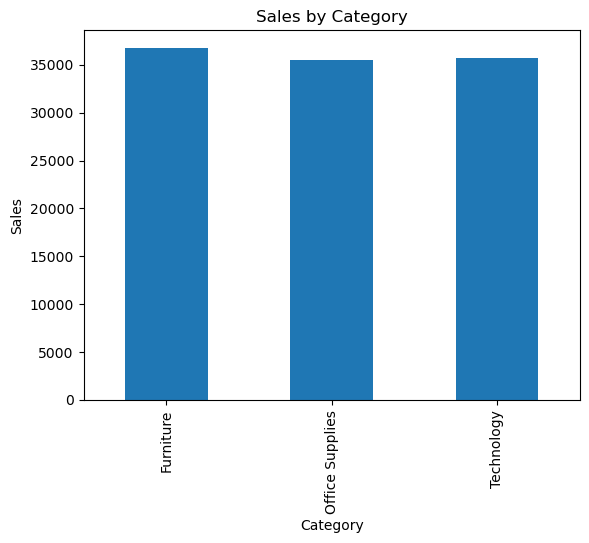

In [20]:
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

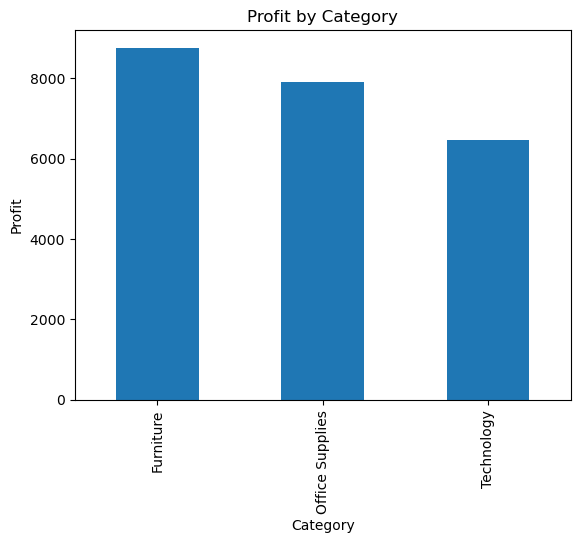

In [21]:
category_profit.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

In [22]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales

Region
Central    32017.38
East       21556.05
South      30201.63
West       24289.96
Name: Sales, dtype: float64

In [23]:
region_profit = df.groupby('Region')['Profit'].sum()
region_profit

Region
Central    6979.91
East       4239.07
South      6171.76
West       5744.86
Name: Profit, dtype: float64

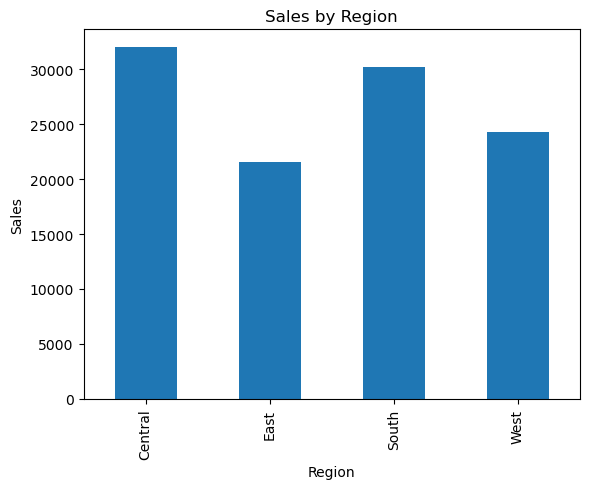

In [24]:
region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

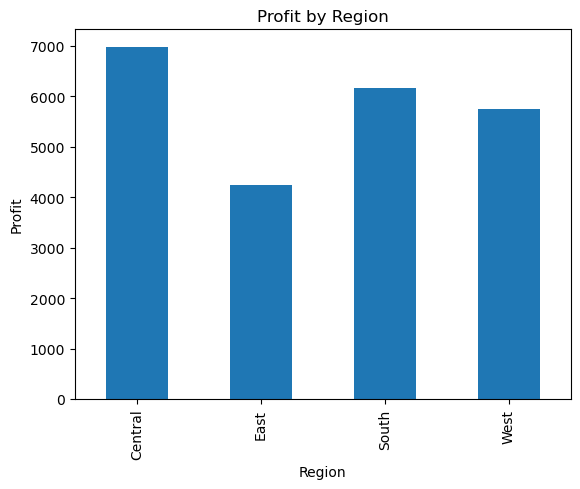

In [25]:
region_profit.plot(kind='bar')
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

In [26]:
segment_sales = df.groupby('Customer Segment')['Sales'].sum()
segment_sales

Customer Segment
Consumer       39646.91
Corporate      33047.31
Home Office    35370.80
Name: Sales, dtype: float64

In [27]:
segment_profit = df.groupby('Customer Segment')['Profit'].sum()
segment_profit

Customer Segment
Consumer       10475.49
Corporate       6585.30
Home Office     6074.81
Name: Profit, dtype: float64

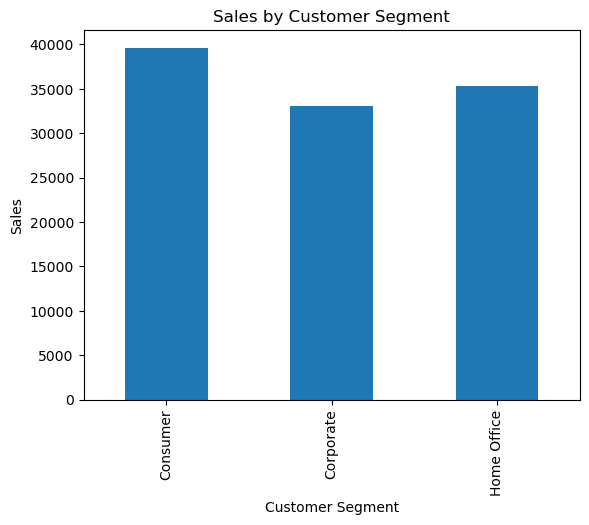

In [28]:
segment_sales.plot(kind='bar')
plt.title('Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Sales')
plt.show()

In [29]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
subcategory_sales

Sub-Category
Tables         21535.86
Phones         20575.49
Storage        20259.33
Accessories    15808.83
Chairs         15267.28
Binders        14618.23
Name: Sales, dtype: float64

In [30]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
subcategory_profit

Sub-Category
Tables         4571.23
Accessories    4501.47
Storage        4010.49
Chairs         3565.85
Binders        3468.88
Phones         3017.68
Name: Profit, dtype: float64

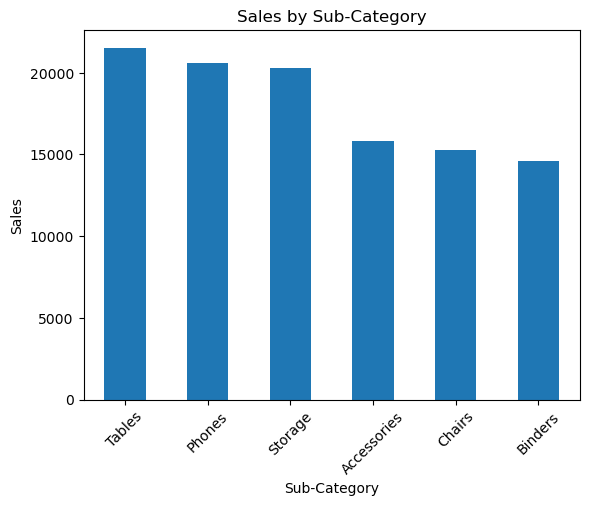

In [31]:
subcategory_sales.plot(kind='bar')
plt.title('Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

In [32]:
df['Month'] = df['Order Date'].dt.month

In [33]:
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

Month
1    15157.87
2    14969.15
3    18461.98
4    17247.74
5    15630.33
6    15880.88
7    10717.07
Name: Sales, dtype: float64

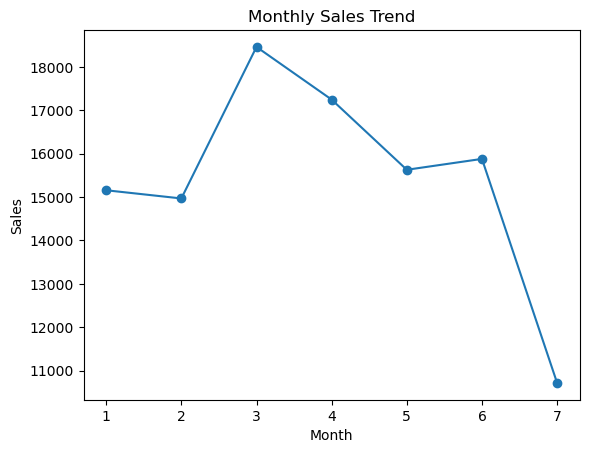

In [34]:
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

In [35]:
category_sales.idxmax()

'Furniture'

In [36]:
category_profit.idxmax()

'Furniture'

In [37]:
region_sales.idxmax()

'Central'

In [38]:
region_profit.idxmax()

'Central'

In [39]:
subcategory_profit.idxmax()

'Tables'

In [40]:
df[['Sales', 'Quantity', 'Profit']].corr()

,Sales,Quantity,Profit
Sales,1.000000,0.043118,-0.007593
Quantity,0.043118,1.000000,-0.078908
Profit,-0.007593,-0.078908,1.000000


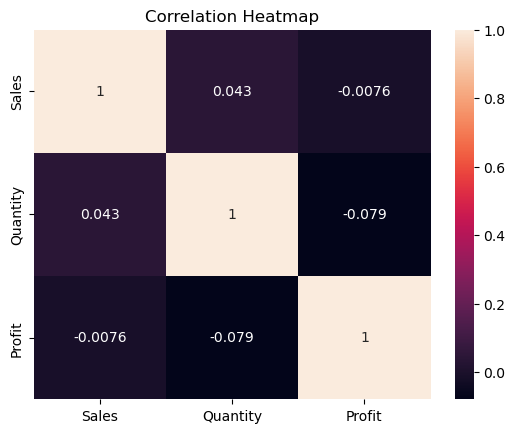

In [42]:
sns.heatmap(df[['Sales', 'Quantity', 'Profit']].corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

## Conclusion

The analysis was performed on the Superstore Sales dataset to understand sales and profit performance. The analysis examined sales based on category, region, sub-category, and customer segment. It also identified sales trends and profitable areas. These insights can help businesses improve sales performance, identify profitable products, and make better business decisions.